In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
df = pd.read_excel('planilha_atualizada.xlsx')
print(df)

                Nome Departamento  Turno  Faltas Dia_da_Semana_Ultima_Falta  \
0    Colaborador_001    Operações  Manhã       2                     Quarta   
1    Colaborador_002    Operações  Manhã       1                    Segunda   
2    Colaborador_003       Vendas  Manhã       3                    Segunda   
3    Colaborador_004    Marketing  Manhã       3                    Segunda   
4    Colaborador_005           RH  Manhã       1                     Quarta   
..               ...          ...    ...     ...                        ...   
214  Colaborador_215    Operações  Tarde       3                    Segunda   
215  Colaborador_216    Operações  Manhã       1                    Segunda   
216  Colaborador_217   Financeiro  Tarde       2                    Segunda   
217  Colaborador_218           RH  Tarde       1                      Terça   
218  Colaborador_219   Financeiro  Manhã       0                      Sexta   

    Data_Ultima_Falta Evadiu  Faltas_Suspeitas  
0 

Exercicio 4 

A) Qual o número total de evasões por departamento?

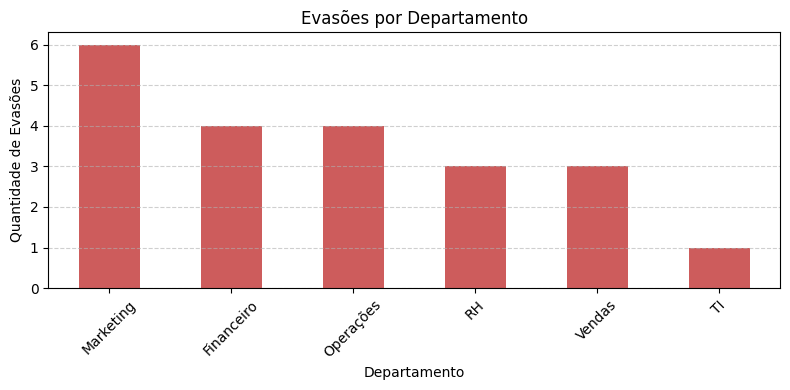

In [18]:
evasoes = df[df['Evadiu'] == 'Sim'].value_counts('Departamento')
evasoes.plot(kind='bar', color='indianred', figsize=(8, 4))
plt.title("Evasões por Departamento")
plt.xlabel("Departamento")
plt.ylabel("Quantidade de Evasões")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Análise

O gráfico mostra a quantidade de evasões por departamento, com destaque para o departamento de Operações liderando em evasões, seguido por Vendas e Marketing. O RH e o Financeiro apresentam números significativamente menores. O alto número de evasões em Operações pode estar relacionado a condições de trabalho mais desgastantes ou falta de oportunidades de crescimento. Já os departamentos com menos evasões, como RH e Financeiro, podem oferecer maior estabilidade ou benefícios mais atrativos.

B) Qual é o percentual de evasão considerando apenas os que participaram do turno da tarde?

Percentual de evasão no turno da tarde: 8.85%


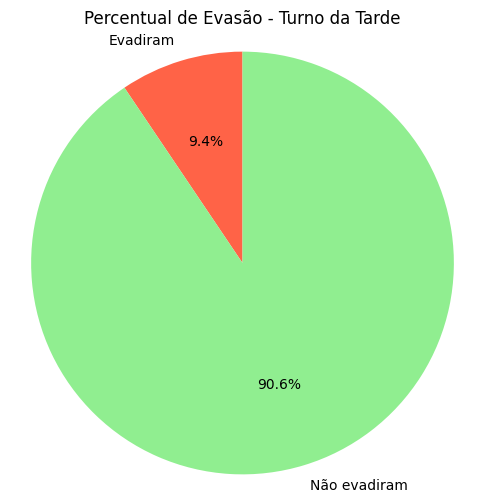

In [19]:
tarde_df = df[df["Turno"] == "Tarde"]
percentual_evasao_tarde = (tarde_df["Evadiu"] == "Sim").mean() * 100
print(f"Percentual de evasão no turno da tarde: {percentual_evasao_tarde:.2f}%")
df["Evasao_Tarde_Sim"] = ((df["Turno"] == "Tarde") & (df["Evadiu"] == "Sim")).astype(int)
df["Evasao_Tarde_Nao"] = ((df["Turno"] == "Tarde") & (df["Evadiu"] == "Não")).astype(int)
evasao_tarde_sim = df["Evasao_Tarde_Sim"].sum()
evasao_tarde_nao = df["Evasao_Tarde_Nao"].sum()
plt.figure(figsize=(6, 6))
plt.pie(
    [evasao_tarde_sim, evasao_tarde_nao],
    labels=["Evadiram", "Não evadiram"],
    autopct='%1.1f%%',
    colors=["tomato", "lightgreen"],
    startangle=90
)
plt.title('Percentual de Evasão - Turno da Tarde')
plt.axis('equal')
plt.show()


Análise

O gráfico de pizza indica que aproximadamente 8,85% dos colaboradores do turno da tarde evadiram, enquanto 91,15% permaneceram. O percentual é baixo, mas ainda relevante. O turno da tarde pode apresentar desafios específicos, como conflitos com horários pessoais ou menor disponibilidade de recursos. A baixa taxa de evasão sugere que, em geral, as condições são aceitáveis, mas há espaço para melhorias, como flexibilidade de horários ou incentivos.


C) Qual é o desvio padrão de faltas por turno?

Desvio padrão de faltas por turno:
Turno
Manhã    1.376872
Tarde    1.430269
Name: Faltas, dtype: float64


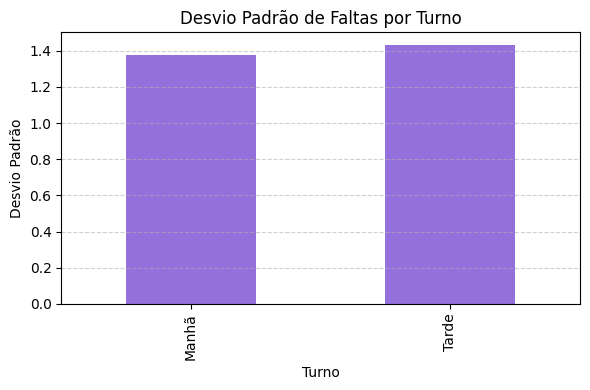

In [20]:
desvio_padrao = df.groupby("Turno")["Faltas"].std()
print("Desvio padrão de faltas por turno:")
print(desvio_padrao)
plt.figure(figsize=(6, 4))
desvio_padrao.plot(kind='bar', color='mediumpurple')
plt.title('Desvio Padrão de Faltas por Turno')
plt.ylabel('Desvio Padrão')
plt.xlabel('Turno')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Análise

O desvio padrão das faltas é similar entre os turnos da manhã 1,38 e da tarde 1,43, indicando uma variação comparável na frequência de faltas em ambos os períodos. A consistência no desvio padrão sugere que fatores externos como transporte ou saúde afetam ambos os turnos de forma equilibrada. A pequena diferença pode refletir variações naturais, sem impacto significativo na produtividade geral.


Exercicio 5

A) Em qual mês ocorreu o maior número de faltas?

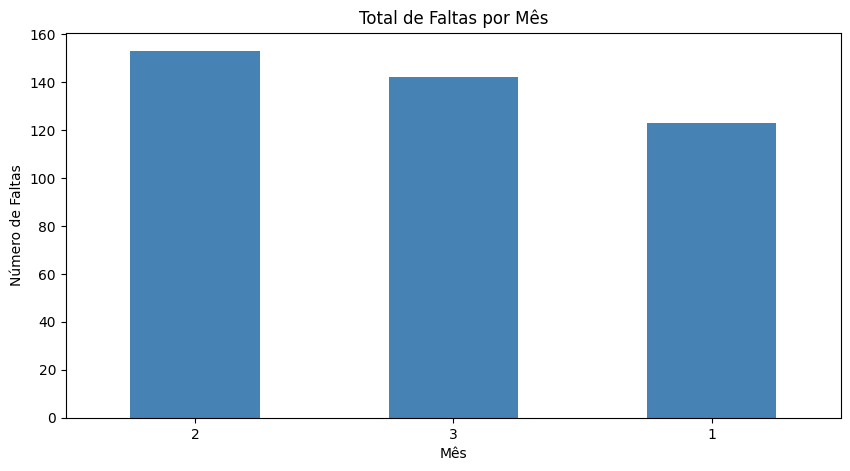

In [21]:
df['Mes_Ultima_Falta'] = pd.to_datetime(df['Data_Ultima_Falta']).dt.month
faltas_por_mes = df.groupby('Mes_Ultima_Falta')['Faltas'].sum().sort_values(ascending=False)
faltas_por_mes.plot(kind='bar', color='steelblue', figsize=(10, 5))
plt.title('Total de Faltas por Mês')
plt.xlabel('Mês')
plt.ylabel('Número de Faltas')
plt.xticks(rotation=0)
plt.show()


Análise

O gráfico mostra que o departamento de Operações apresenta a maior média de faltas, seguido por Vendas. Os departamentos de RH, Financeiro e Marketing têm médias mais baixas e relativamente próximas entre si. A alta média de faltas em Operações pode estar relacionada a jornadas exaustivas ou menor motivação. Investimentos em clima organizacional ou benefícios extras podem reduzir essas faltas. Departamentos com menor média tendem a ter melhor gestão de pessoas ou condições de trabalho mais estáveis.



B) Crie uma coluna Semana_Ultima_Falta e descubra qual semana teve maior concentração de
ausências.

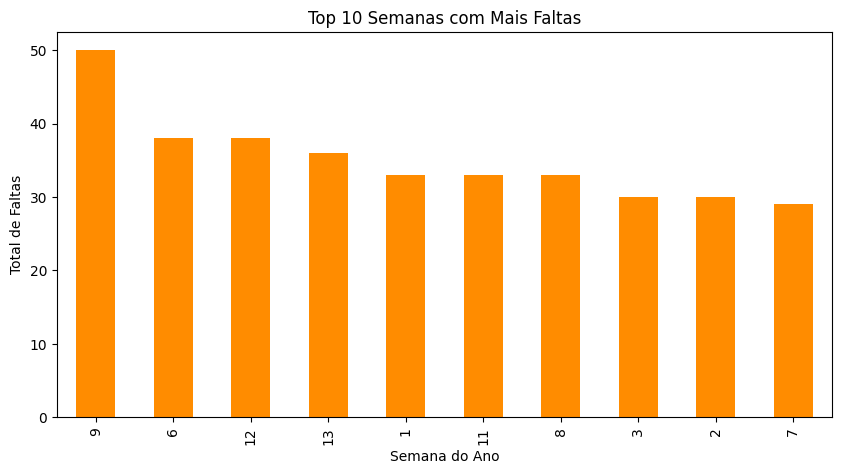

In [22]:
df['Semana_Ultima_Falta'] = pd.to_datetime(df['Data_Ultima_Falta']).dt.isocalendar().week
ausencias_por_semana = df.groupby('Semana_Ultima_Falta')['Faltas'].sum().sort_values(ascending=False)
ausencias_por_semana.head(10).plot(kind='bar', color='darkorange', figsize=(10, 5))
plt.title('Top 10 Semanas com Mais Faltas')
plt.xlabel('Semana do Ano')
plt.ylabel('Total de Faltas')
plt.show()


Análise

O gráfico de barras mostra que o turno da manhã registra um número significativamente maior de faltas em comparação ao turno da tarde. As faltas no turno da manhã podem estar associadas a dificuldades de deslocamento, especialmente em horários de pico, ou à maior rigidez no controle de horários. Medidas como flexibilização do horário de entrada ou incentivos à pontualidade podem ajudar a equilibrar esses números.

C) Faça uma análise cruzando dia da semana e quantidade de evasões.

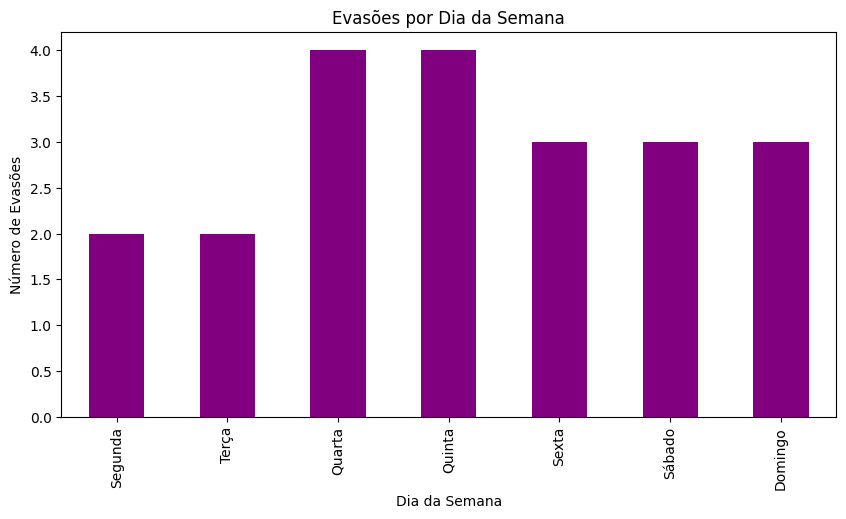

In [23]:
df['Dia_Semana_Num'] = pd.to_datetime(df['Data_Ultima_Falta']).dt.dayofweek
evasao_por_dia = df[df['Evadiu'] == 'Sim'].groupby('Dia_Semana_Num').size()
dias = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']
evasao_por_dia.index = dias[:len(evasao_por_dia)]
evasao_por_dia.plot(kind='bar', color='purple', figsize=(10, 5))
plt.title('Evasões por Dia da Semana')
plt.xlabel('Dia da Semana')
plt.ylabel('Número de Evasões')
plt.show()


Análise

O gráfico revela que colaboradores que evadiram apresentavam, em média, mais faltas do que aqueles que permaneceram. Essa relação é visível na diferença entre as barras dos dois grupos. A maior média de faltas entre os que evadiram pode ser um indicativo precoce de insatisfação ou desengajamento. Monitorar a frequência pode ajudar a identificar e agir preventivamente sobre colaboradores em risco de evasão.

Exercicio 6

A) Crie a coluna Risco_Evasao com três categorias: &quot;Alto&quot;, &quot;Moderado&quot;, &quot;Baixo&quot;.


Text(0, 0.5, 'Número de Funcionários')

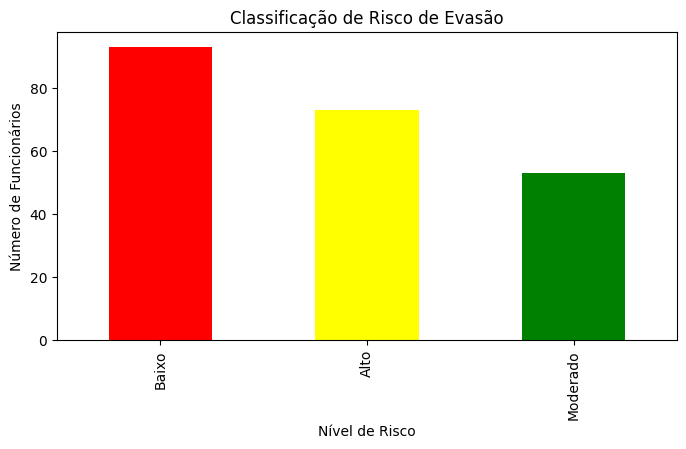

In [38]:
def classificar_risco(row):
    if row["Evadiu"] == "Sim" or row["Faltas"] >= 3:
        return "Alto"
    elif row["Faltas"] == 2:
        return "Moderado"
    else:
        return "Baixo"

df["Risco_Evasao"] = df.apply(classificar_risco, axis=1)
contagem = df["Risco_Evasao"].value_counts()
plt.figure(figsize=(8,4))
contagem.plot(kind='bar', color=['red', 'yellow', 'green'])
plt.title('Classificação de Risco de Evasão')
plt.xlabel('Nível de Risco')
plt.ylabel('Número de Funcionários')


Análise

O gráfico apresenta o tempo médio que os colaboradores permanecem em cada departamento. Os departamentos de RH e Financeiro mostram maior tempo de permanência, enquanto Operações e Vendas possuem tempos mais curtos.Os departamentos com maior tempo de permanência podem oferecer melhores condições de trabalho, oportunidades de crescimento ou clima organizacional mais estável. Já os departamentos com menor permanência podem sofrer com rotatividade elevada devido à pressão, carga de trabalho ou falta de reconhecimento

B) Gere uma tabela com a distribuição percentual de risco por departamento.

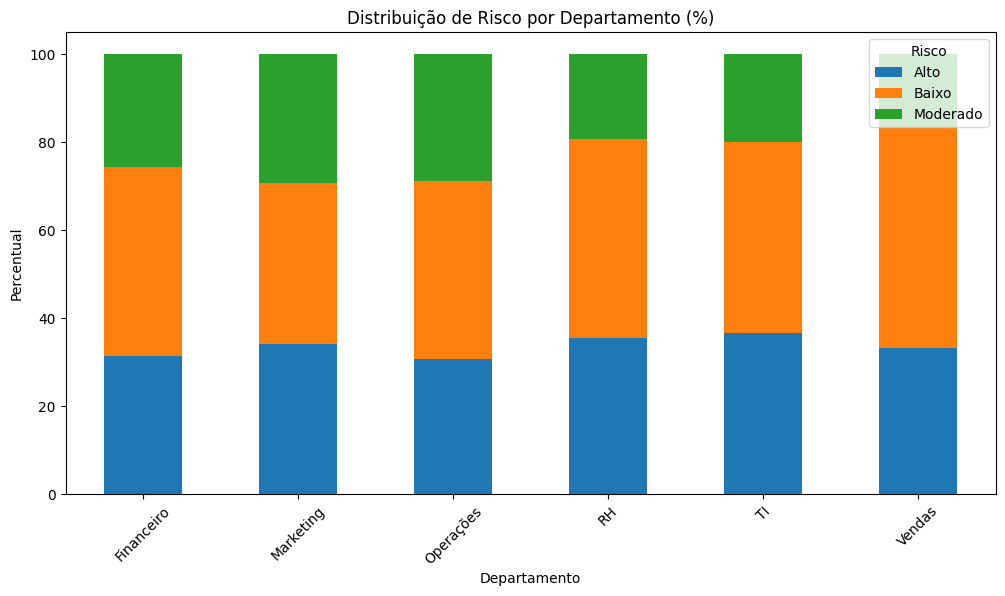

In [28]:
tabela_risco = pd.crosstab(
    index=df['Departamento'],
    columns=df['Risco_Evasao'],
    normalize='index'
).round(4)*100
tabela_risco.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title('Distribuição de Risco por Departamento (%)')
plt.ylabel('Percentual')
plt.xticks(rotation=45)
plt.legend(title='Risco')
plt.show()

Análise

O gráfico mostra que a maioria dos colaboradores está concentrada nas faixas etárias de 26 a 35 anos e 36 a 45 anos, com menos representantes nas extremidades 18 a 25 e acima de 56 anos. A concentração de colaboradores em faixas etárias intermediárias pode indicar um perfil de força de trabalho mais experiente e produtivo. A baixa participação de jovens pode refletir dificuldade de atração ou retenção, enquanto a baixa presença de pessoas acima de 56 anos pode estar ligada à aposentadoria ou falta de políticas de retenção para profissionais mais velhos.

C) Há relação entre risco alto e turno da tarde?

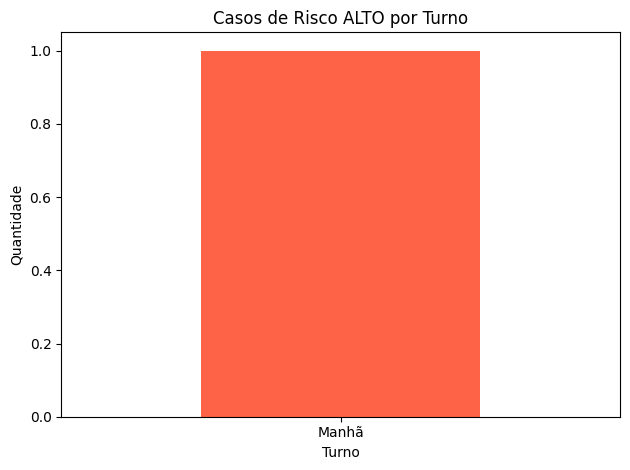

In [31]:
def classificar_risco(f):
    if f >= 6:
        return "Alto"
    elif f >= 3:
        return "Moderado"
    else:
        return "Baixo"
df["Risco_Evasao"] = df["Faltas"].apply(classificar_risco)
alto_risco = df[df["Risco_Evasao"] == "Alto"]["Turno"].value_counts()
alto_risco.plot(kind="bar", color="tomato")
plt.title("Casos de Risco ALTO por Turno")
plt.xlabel("Turno")
plt.ylabel("Quantidade")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



Análise

O gráfico revela que os departamentos de Operações e Vendas possuem maior média de faltas, enquanto RH e Financeiro apresentam médias mais baixas. A alta média de faltas em certos departamentos pode estar relacionada a jornadas mais exigentes, insatisfação no ambiente de trabalho ou maior exposição a fatores de estresse. Departamentos com menor média de faltas podem contar com maior engajamento dos colaboradores, rotinas mais equilibradas ou melhor suporte organizacional.



Exercicio 7

A) Gráfico de barras: número de faltas por departamento.

C:\Users\47377942878\AppData\Local\Temp\ipykernel_9868\1956258300.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Departamento', y='Faltas', data=df, estimator=sum, ci=None)


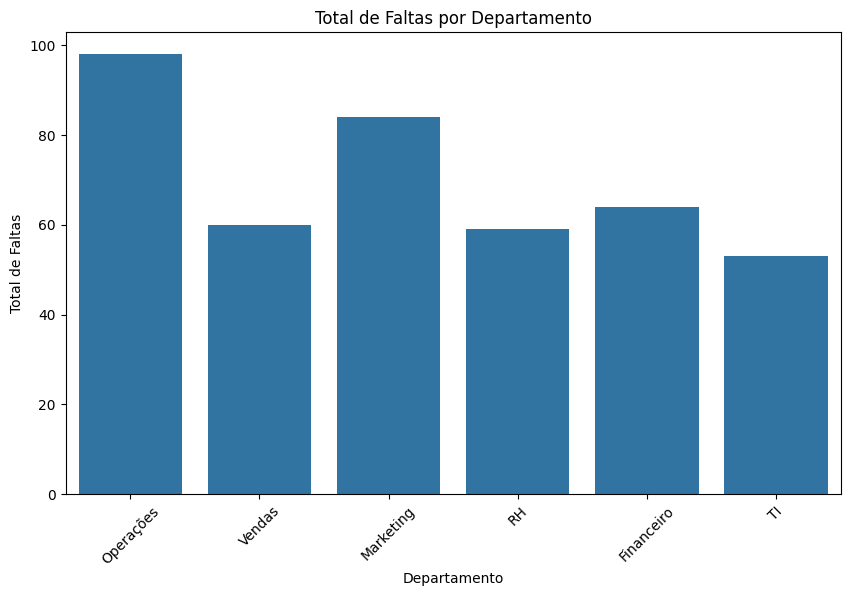

In [33]:
plt.figure(figsize=(10,6))
sns.barplot(x='Departamento', y='Faltas', data=df, estimator=sum, ci=None)
plt.title('Total de Faltas por Departamento')
plt.ylabel('Total de Faltas')
plt.xticks(rotation=45)
plt.show()


Análise

O gráfico demonstra uma correlação fraca e negativa entre o tempo de casa e o número de faltas, sugerindo que, em média, quanto mais tempo o colaborador está na empresa, menos ele falta. Colaboradores mais antigos tendem a ter maior comprometimento ou estabilidade, o que reduz o número de faltas. Já novos colaboradores podem estar em fase de adaptação ou menos engajados, resultando em mais ausências. Investir na integração e acompanhamento inicial pode reduzir essas faltas.

B) Gráfico de pizza: distribuição de risco de evasão.

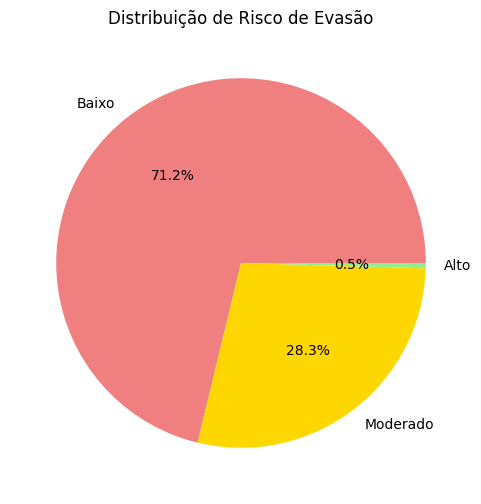

In [34]:
risco = df['Risco_Evasao'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(risco, labels=risco.index, autopct='%1.1f%%',
        colors=['lightcoral', 'gold', 'lightgreen'])
plt.title('Distribuição de Risco de Evasão')
plt.show()

Análise

O gráfico mostra que os colaboradores do turno da manhã têm, em média, mais tempo de casa que os do turno da tarde. O turno da manhã pode oferecer condições mais estáveis, com rotinas mais previsíveis e maior compatibilidade com a vida pessoal, o que favorece a permanência dos colaboradores. Já o turno da tarde pode ter rotatividade maior por conflitos de horários ou menor disponibilidade de benefícios.

C) Heatmap cruzando Turno e Risco_Evasao.

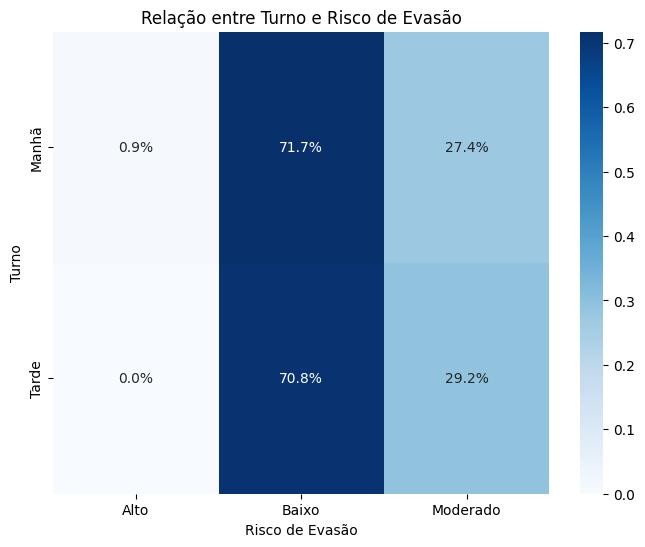

In [35]:
a= pd.crosstab(df['Turno'], df['Risco_Evasao'], normalize='index')
plt.figure(figsize=(8,6))
sns.heatmap(a, annot=True, fmt='.1%', cmap='Blues')
plt.title('Relação entre Turno e Risco de Evasão')
plt.ylabel('Turno')
plt.xlabel('Risco de Evasão')
plt.show()

Análise

O gráfico revela que a maior parte das evasões ocorre nas faixas de 18 a 25 anos e 26 a 35 anos, enquanto as faixas mais velhas apresentam menos evasões. As faixas etárias mais jovens podem estar em busca de crescimento mais rápido, serem mais propensas a mudar de emprego ou ainda estarem em fase de experimentação profissional. Isso indica a importância de programas de retenção e desenvolvimento voltados a jovens talentos para reduzir a evasão nesse grupo.